In [1]:
import numpy as np
import pandas as pd
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns

In [ ]:
savepath = "experiments/results/lassocv"
p = 20
s = 3
signal_fac = 0.
rho = 0.9
coverages = {}
lengths = {}
false_rejects = {}
for nu_sq in [0., 0.1]:
    nu = np.sqrt(nu_sq) 
    if nu > 0:
        methods = ['naive', 'splitting', 'bivnormal', 'sov', 'adjusted_bivnormal', 'adjusted_sov']
    else:
        methods = ['naive', 'hard_threshold', 'adjusted_hard_threshold']
    
    for key in methods:
        coverages[(nu_sq, key)] = []
        lengths[(nu_sq, key)] = []
        false_rejects[(nu_sq, key)] = []
    count = 0
    for seed in range(1000):
        filename = f"lassocv_100_{p}_{s}_{round(nu, 3)}_{signal_fac}_rho_{rho}_train_2000_val_500_hidden_8/{seed}.pkl"
        try:
            with open(os.path.join(savepath, filename), 'rb') as f:
                res = pickle.load(f)
        except:
            continue
        count += 1
        for key in methods:
            coverages[(nu_sq, key)].append(np.mean(res['coverages'][key]))
            lengths[(nu_sq, key)].append(np.mean(res['intervals'][key][:, 1] - res['intervals'][key][:, 0]))
            false_rejects[(nu_sq, key)].append(np.mean(res['pvalues'][key] < 0.05))
    print(nu_sq, count)

0.0 270
0.1 273


In [3]:
max_len = 273
for key, item in coverages.items():
    if len(item) < max_len:
        item += [np.nan] * (max_len - len(item))
    coverages[key] = item[:max_len]

for key, item in lengths.items():
    if len(item) < max_len:
        item += [np.nan] * (max_len - len(item))
    lengths[key] = item[:max_len]

df_cover = pd.DataFrame(coverages).melt().rename(columns={'variable_0': 'nusq', 'variable_1': 'method', 'value': 'coverage'})
df_len = pd.DataFrame(lengths).melt().rename(columns={'variable_0': 'nusq', 'variable_1': 'method', 'value': 'length'})

In [4]:
color_list = {
    'naive': '#999999',
    'hard_threshold': '#fcae91',
    'bivnormal': '#9ecae1',
    'sov': '#a1d99b',
    'adjusted_hard_threshold': '#de2d26',
    'adjusted_bivnormal': '#3182bd',
    'adjusted_sov': '#31a354',
    'splitting': '#756bb1'
}
methods = ['naive', 'splitting', 'hard_threshold', 'bivnormal', 'sov', 'adjusted_hard_threshold', 'adjusted_bivnormal', 'adjusted_sov']

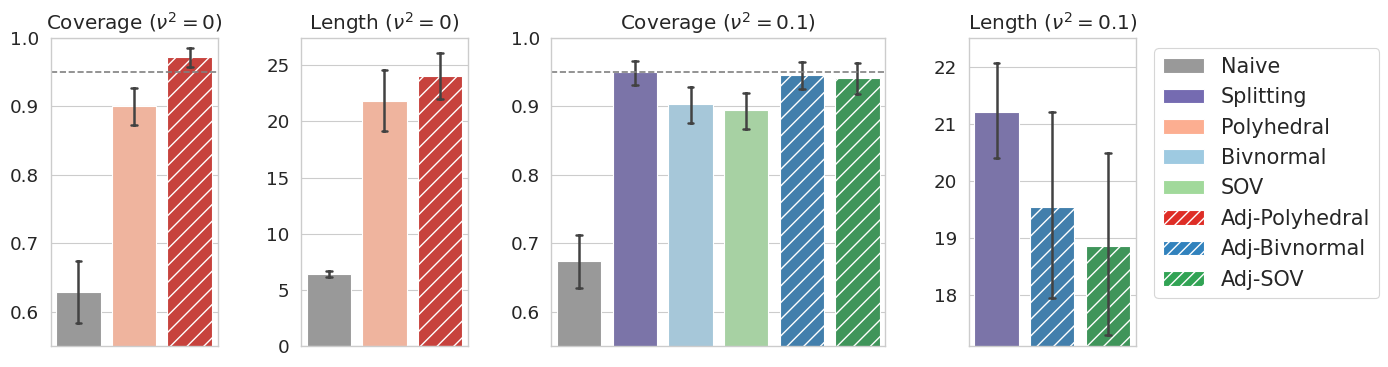

In [ ]:
sns.set_theme(context='paper', style='whitegrid', font_scale=1.5)
fig = plt.figure(figsize=(14, 4))  # width x height in inches
widths = [1, 1, 2, 1]  # relative widths of the 4 subplots

gs = gridspec.GridSpec(1, 4, width_ratios=widths, wspace=0.4)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])
ax4 = fig.add_subplot(gs[3])
axes = [ax1, ax2, ax3, ax4]

# coverage nu=0
sns.barplot(ax=ax1, data=df_cover[df_cover['nusq'] == 0.], x='method', hue='method', y='coverage', hue_order=methods, palette=color_list, capsize=.1)
ax1.axhline(0.95, color='grey', ls='--')
ax1.set_ylim(0.55, 1)
bars = ax1.patches
bars[-1].set_hatch('//')
ax1.set_title(r'Coverage ($\nu^2=0$)')

# length nu=0
sns.barplot(ax=ax2, data=df_len[df_len['nusq'] == 0.], x='method', hue='method', y='length', hue_order=methods, palette=color_list, capsize=.1)
bars = ax2.patches
bars[-1].set_hatch('//')
ax2.set_title(r'Length ($\nu^2=0$)')

# coverage nu=.1
sns.barplot(ax=ax3, data=df_cover[df_cover['nusq'] == 0.1], x='method', hue='method', y='coverage', hue_order=methods, palette=color_list, capsize=.1)
ax3.axhline(0.95, color='grey', ls='--')
ax3.set_ylim(0.55, 1)

bars = ax3.patches
bars[-2].set_hatch('//')
bars[-1].set_hatch('//')
ax3.set_title(r'Coverage ($\nu^2=0.1$)')

# length nu=.1
df_len_2 = df_len[(df_len['nusq'] == 0.1) & (df_len['method'].isin(['adjusted_bivnormal', 'adjusted_sov', 'splitting']))]
sns.barplot(ax=ax4, data=df_len_2, x='method', hue='method', y='length', hue_order=methods, palette=color_list, capsize=.1)
bars = ax4.patches
bars[-2].set_hatch('//')
bars[-1].set_hatch('//')
ax4.set_title(r'Length ($\nu^2=0.1$)')
ax4.set_ylim(17.1, 22.5)

for ax in axes:
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_xticks([])


labels = ['Naive', 'Splitting', 'Polyhedral', 'Bivnormal', 'SOV', 'Adj-Polyhedral', 'Adj-Bivnormal', 'Adj-SOV']
colors = {
    'Naive': '#999999',
    'Polyhedral': '#fcae91',
    'Bivnormal': '#9ecae1',
    'SOV': '#a1d99b',
    'Adj-Polyhedral': '#de2d26',
    'Adj-Bivnormal': '#3182bd',
    'Adj-SOV': '#31a354',
    'Splitting': '#756bb1'
}
hatches = {
    'Naive': '',
    'Polyhedral': '',
    'Bivnormal': '',
    'SOV': '',
    'Adj-Polyhedral': '///',
    'Adj-Bivnormal': '///',
    'Adj-SOV': '///',
    'Splitting': ''
}

legend_patches = [
    Patch(facecolor=colors[m], hatch=hatches[m], edgecolor=None, label=m)
    for m in labels
]

plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=15)
